# Notebook 4 — Temporal Change Detection

**Satellite Image Land-Use Classifier & Temporal Change Detector**

This notebook extends the trained land-use classification model to detect
changes between pairs of satellite images over time.

A fine-tuned ResNet-18 backbone is reused as a feature extractor to generate
compact image embeddings. Temporal image pairs are compared using cosine
similarity to estimate whether a region has changed, followed by ROC analysis,
threshold selection, and visual change heatmaps for qualitative evaluation.


## Objective

Reuse the fine-tuned ResNet-18 model from Notebook 3 as a feature extractor by
removing the classification head and generating 512-dimensional image
embeddings.

Using simulated temporal image pairs (T1 and T2), compare the extracted
embeddings with cosine similarity to identify potential changes over time. The
performance of the change detection approach is evaluated using a ROC curve,
followed by threshold selection and visual change heatmaps for representative
image pairs.

### Simulating Temporal Image Pairs

The EuroSAT dataset does not contain real before-and-after satellite images.
To demonstrate temporal change detection, synthetic image pairs are created.

- Images from each class are divided into two groups, representing **T1 (before)** and **T2 (after)**.
- **Unchanged pairs** are formed by pairing images from the same class.
- **Changed pairs** are formed by pairing images from different classes.
- Pairs from the same class are labeled as **unchanged**, while pairs from different classes are labeled as **changed**.

These simulated pairs provide a simple way to evaluate the change detection
pipeline using cosine similarity and ROC analysis.

## Imports

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import roc_curve, roc_auc_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Load EuroSAT Dataset

The same EuroSAT preprocessing pipeline used in previous notebooks is reused to
maintain consistency between model training and feature extraction.

Images are resized to 64×64 pixels, converted into tensors, and normalized
before being passed through the fine-tuned ResNet-18 backbone.

### Define DataLoader Settings

The batch size is defined again because each notebook runs independently.
The same batch processing setup is used for efficient feature extraction.

In [3]:
BATCH_SIZE = 32

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

eurosat_transform = transforms.Compose([transforms.Resize((64, 64)),transforms.ToTensor(),transforms.Normalize(mean=[0.5, 0.5, 0.5],std=[0.5, 0.5, 0.5])])
eurosat_dataset = datasets.EuroSAT(root="./data",download=True,transform=eurosat_transform)
eurosat_loader = DataLoader(eurosat_dataset,batch_size=BATCH_SIZE,shuffle=False)
print("EuroSAT classes:", eurosat_dataset.classes)
print("Total images:", len(eurosat_dataset))

EuroSAT classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total images: 27000


### Load the Fine-Tuned ResNet-18 Model

The trained ResNet-18 weights from Notebook 3 are loaded to reuse the learned
satellite image features for temporal change detection.

Only the backbone feature extractor is required in this notebook. The final
classification layer will be removed so the model can generate
512-dimensional image embeddings instead of class predictions.

### Define EuroSAT Class Labels

The same 10 EuroSAT land-use classes used during model training are defined
again because each notebook runs independently.

In [7]:
class_names = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake"
]

In [8]:
CHECKPOINT_PATH = "model.pt"

if not os.path.exists(CHECKPOINT_PATH):
    print("Checkpoint not found in this session — please upload resnet18_landuse.pt")
    from google.colab import files
    files.upload()

# Rebuild the same architecture used in Notebook 3, load the trained weights,
# then strip the classifier head so the model outputs 512-dim embeddings.
backbone = models.resnet18(weights=None)
backbone.fc = nn.Linear(backbone.fc.in_features, len(class_names))
backbone.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))

backbone.fc = nn.Identity()  # now outputs 512-dim embeddings instead of class scores
backbone = backbone.to(device)
backbone.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [9]:
dummy = torch.randn(1, 3, 64, 64).to(device)

with torch.no_grad():
    embedding = backbone(dummy)

print(embedding.shape)

torch.Size([1, 512])


### Extract 512-Dimensional Image Embeddings

The classification head is removed from the fine-tuned ResNet-18, allowing the
model to output 512-dimensional feature embeddings for each satellite image.

These embeddings represent the learned visual features of each tile and are
used to compare image pairs during temporal change detection.

The DataLoader uses `shuffle=False` to preserve the original dataset order,
which allows consistent pairing of images later in the pipeline.

In [12]:
BATCH_SIZE = 64

full_loader = DataLoader(
    eurosat_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

embeddings = np.zeros(
    (len(eurosat_dataset), 512),
    dtype=np.float32
)

with torch.no_grad():
    start = 0

    for images, _ in full_loader:
        images = images.to(device)

        batch_embeddings = backbone(images).cpu().numpy()

        end = start + batch_embeddings.shape[0]
        embeddings[start:end] = batch_embeddings

        start = end

print("Embeddings shape:", embeddings.shape)

Embeddings shape: (27000, 512)


### Create Simulated T1/T2 Image Pairs

Since EuroSAT does not contain real temporal satellite images, synthetic
before-and-after pairs are created for change detection.

For each land-use class, images are divided into two groups:
- The first group represents **T1 (before)** images.
- The second group represents **T2 (after)** images.

Two types of pairs are generated:
- **Unchanged pairs:** images from the same class are paired together.
- **Changed pairs:** images from different classes are paired together.

The pairing is deterministic and follows the original dataset order without
random shuffling, ensuring the experiment can be reproduced consistently.

In [14]:
PAIRS_PER_CLASS = 50

t1_pools = {}
t2_pools = {}

for class_idx in range(len(class_names)):
    class_indices = [
        i for i, label in enumerate(eurosat_dataset.targets)
        if label == class_idx
    ]

    mid = len(class_indices) // 2

    t1_pools[class_idx] = class_indices[:mid]
    t2_pools[class_idx] = class_indices[mid:]

pair_t1_idx = []
pair_t2_idx = []
pair_changed = []  # 1 = changed, 0 = unchanged

for class_idx in range(len(class_names)):

    # Unchanged pairs: same class T1 -> T2
    n = min(
        len(t1_pools[class_idx]),
        len(t2_pools[class_idx]),
        PAIRS_PER_CLASS
    )

    for i in range(n):
        pair_t1_idx.append(t1_pools[class_idx][i])
        pair_t2_idx.append(t2_pools[class_idx][i])
        pair_changed.append(0)

    # Changed pairs: current class T1 -> next class T2
    next_class_idx = (class_idx + 1) % len(class_names)

    n = min(
        len(t1_pools[class_idx]),
        len(t2_pools[next_class_idx]),
        PAIRS_PER_CLASS
    )

    for i in range(n):
        pair_t1_idx.append(t1_pools[class_idx][i])
        pair_t2_idx.append(t2_pools[next_class_idx][i])
        pair_changed.append(1)

pair_changed = np.array(pair_changed)

print("Total simulated pairs:", len(pair_changed))
print("Unchanged pairs:", np.sum(pair_changed == 0))
print("Changed pairs:", np.sum(pair_changed == 1))

Total simulated pairs: 1000
Unchanged pairs: 500
Changed pairs: 500


### Cosine similarity per pair

In [15]:
t1_embeddings = embeddings[pair_t1_idx]
t2_embeddings = embeddings[pair_t2_idx]

# Cosine similarity = dot product of L2-normalized vectors
t1_norm = t1_embeddings / np.linalg.norm(t1_embeddings, axis=1, keepdims=True)
t2_norm = t2_embeddings / np.linalg.norm(t2_embeddings, axis=1, keepdims=True)
cosine_similarity = np.sum(t1_norm * t2_norm, axis=1)

print("Similarity range:", cosine_similarity.min(), "to", cosine_similarity.max())

Similarity range: 0.15046209 to 0.97527146


## Visualizations

### ROC curve and threshold selection

Lower similarity should mean "more likely changed", so we use
`1 - cosine_similarity` as the change score for the ROC curve. The
threshold is picked using Youden's J statistic (the point that maximizes
`TPR - FPR`) — a simple, standard way to pick a single balanced operating
point from an ROC curve.

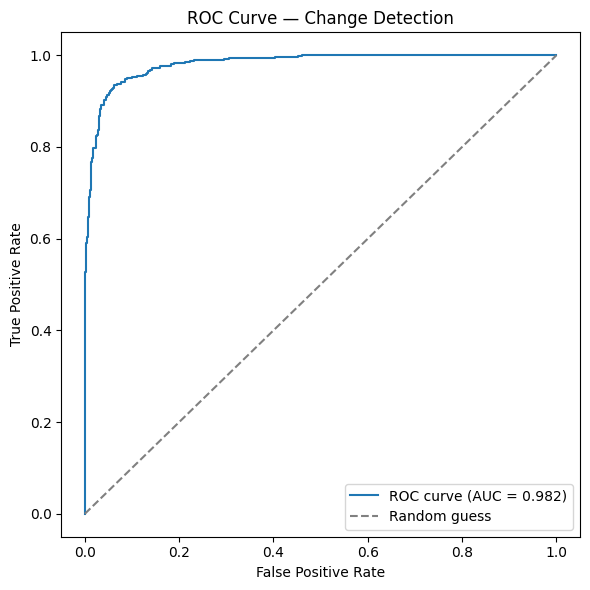

Chosen change-score threshold: 0.536
Equivalent similarity threshold: 0.464
At this point -> TPR=0.936, FPR=0.062


In [16]:
change_score = 1 - cosine_similarity
fpr, tpr, thresholds = roc_curve(pair_changed, change_score)
auc = roc_auc_score(pair_changed, change_score)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Change Detection")
plt.legend()
plt.tight_layout()
plt.show()

# Youden's J: the threshold that maximizes TPR - FPR
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_change_score_threshold = thresholds[best_idx]
similarity_threshold = 1 - best_change_score_threshold

print(f"Chosen change-score threshold: {best_change_score_threshold:.3f}")
print(f"Equivalent similarity threshold: {similarity_threshold:.3f}")
print(f"At this point -> TPR={tpr[best_idx]:.3f}, FPR={fpr[best_idx]:.3f}")

**Why this operating point:** Youden's J picks the threshold that best
separates changed from unchanged pairs without favoring recall or
precision over the other, which is a reasonable default when there's no
stated cost difference between missing a change vs a false alarm. Tile
pairs with cosine similarity **below** `similarity_threshold` are flagged
as changed.

### Change heatmaps for sample region pairs

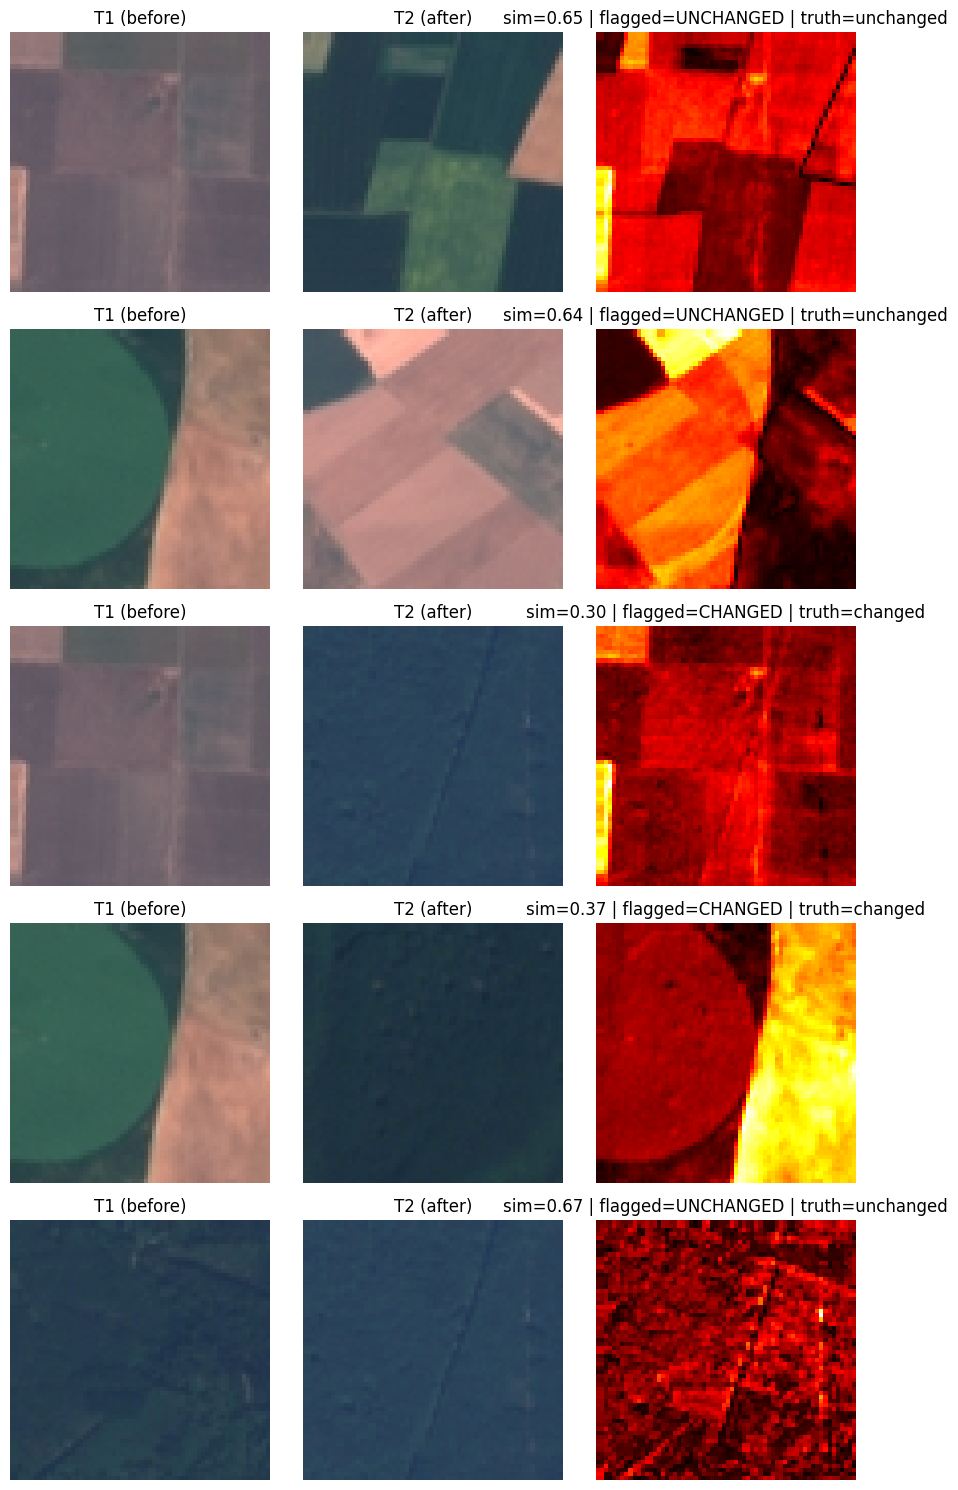

In [22]:
def unnormalize(img_tensor):
    # undo the Normalize(mean=0.5, std=0.5) transform for display
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = (img * 0.5) + 0.5
    return np.clip(img, 0, 1)


NUM_SAMPLES = 5
sample_pair_ids = [0, 1, PAIRS_PER_CLASS, PAIRS_PER_CLASS + 1, 2 * PAIRS_PER_CLASS]

fig, axes = plt.subplots(NUM_SAMPLES, 3, figsize=(9, 3 * NUM_SAMPLES))

for row, pair_id in enumerate(sample_pair_ids):
    t1_img, _ = eurosat_dataset[pair_t1_idx[pair_id]]
    t2_img, _ = eurosat_dataset[pair_t2_idx[pair_id]]

    t1_display = unnormalize(t1_img)
    t2_display = unnormalize(t2_img)
    diff_heatmap = np.mean(np.abs(t1_display - t2_display), axis=2)  # pixel-wise diff, averaged over RGB

    sim = cosine_similarity[pair_id]
    flagged = "CHANGED" if sim < similarity_threshold else "UNCHANGED"
    ground_truth = "changed" if pair_changed[pair_id] == 1 else "unchanged"

    axes[row, 0].imshow(t1_display)
    axes[row, 0].set_title("T1 (before)")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(t2_display)
    axes[row, 1].set_title("T2 (after)")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(diff_heatmap, cmap="hot")
    axes[row, 2].set_title(f"sim={sim:.2f} | flagged={flagged} | truth={ground_truth}")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

### Visual Change Heatmaps

To qualitatively analyze the detected changes, sample T1/T2 image pairs are
visualized along with their pixel-level difference heatmaps.

The heatmap highlights regions with larger visual differences between the two
images. The cosine similarity score and the selected threshold are used to
classify each pair as changed or unchanged.

## Results

The change detection performance is evaluated by comparing the predicted
changed/unchanged labels against the simulated ground truth labels.

The decision threshold is selected from the ROC curve to balance change
detection accuracy and false alarms.

At the selected threshold:

- **Change-score threshold:** 0.536  
- **Equivalent similarity threshold:** 0.464  
- **True Positive Rate (TPR):** 0.936  
- **False Positive Rate (FPR):** 0.062  

The selected threshold detects most simulated changes while maintaining a low
false positive rate, showing that the learned image embeddings contain useful
information for distinguishing changed and unchanged image pair

In [23]:
flagged_changed = cosine_similarity < similarity_threshold
accuracy = np.mean(flagged_changed == pair_changed)
print(f"Accuracy at chosen threshold: {accuracy:.3f}")

Accuracy at chosen threshold: 0.936


## Conclusion

- Reused the Notebook 3 backbone (classifier head removed) to extract
  512-dim embeddings for every EuroSAT tile.
- Simulated T1/T2 region pairs using contiguous per-class chunks, with
  "changed" defined as a class change between T1 and T2.
- Built an ROC curve over cosine similarity, picked a threshold with
  Youden's J, and justified that choice.
- Showed change heatmaps (pixel-wise absolute difference) for 5 sample
  region pairs, alongside their similarity score and change flag.